In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

data = pd.read_csv("/content/analiznew.csv", encoding="latin1")


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
data.tail(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Profit Margin
9991,9992,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932,2017,2,0.075
9992,9993,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200,2017,2,0.450
9993,9994,CA-2017-119914,2017-05-04,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480,2017,5,0.300


In [ ]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
data.shape

(9994, 21)

In [ ]:
data.isnull().sum()
data.dropna(inplace=True)


In [ ]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [ ]:
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month

In [ ]:
data['Profit Margin'] = data['Profit'] / data['Sales']

In [ ]:
Q1 = data['Sales'].quantile(0.25)
Q3 = data['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['Sales'] < lower) | (data['Sales'] > upper)]

In [ ]:
Q1 = data['Profit'].quantile(0.25)
Q3 = data['Profit'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_p = data[(data['Profit'] < lower) | (data['Profit'] > upper)]

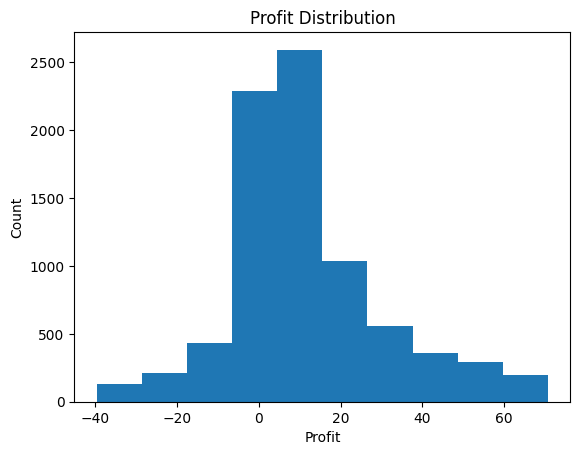

In [ ]:
data_clean = data[(data['Profit'] >= lower) & (data['Profit'] <= upper)]
plt.hist(data_clean['Profit'], bins=10)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Count")
plt.show()


In [ ]:
import statistics as st
mean=data_clean['Profit'].mean()
median=st.median(data_clean['Profit'])
mode=st.mode(data_clean['Profit'])
std=np.std(data_clean['Profit'])

In [ ]:
print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)
print("Standard Deviation:", std)

Mean: 11.604085985455443
Median: 7.2576
Mode: 0.0
Standard Deviation: 18.640275895928237


In [ ]:
#Mean və median dəyərlərin yaxın olması göstərir ki, datasetin paylanması nisbətən balanslıdır,
#Standart sapma(std) nisbətən böyükdür, yəni Profit dəyərləri orta ətrafında kifayət qədər yayılıb.

In [ ]:
data_clean[['Profit']][(data_clean[['Profit']]>(mean-std)) & (data_clean[['Profit']]<(mean+std))].count()

,0
Profit,6190


In [ ]:
#Datasetin çoxu mean ± 1 std intervalında yerləşir, yəni outlier-lər çıxarıldıqdan sonra Profit dəyərlərin coxu normal diapazondadır.”

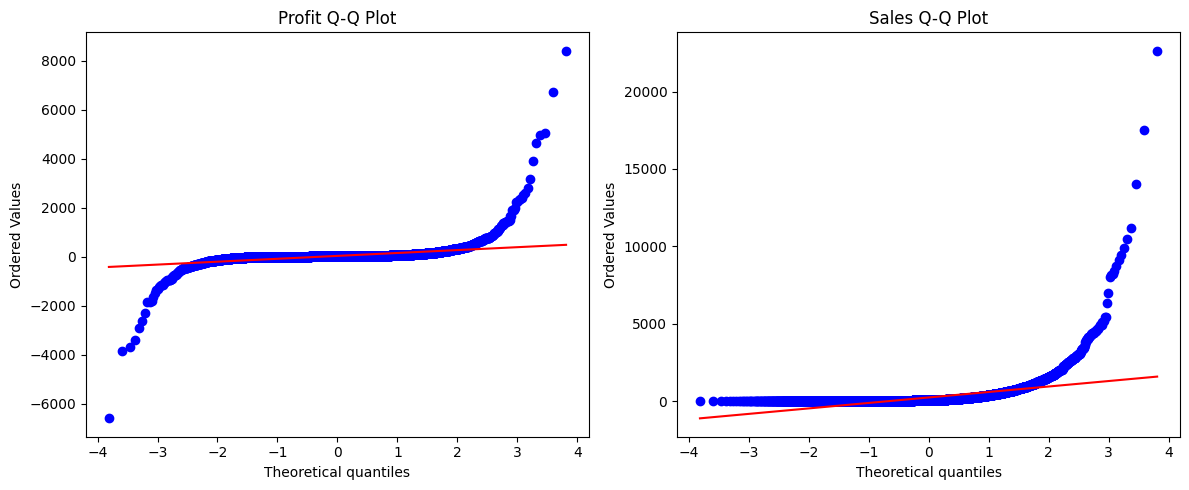

In [ ]:
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Profit üçün Q-Q plot
stats.probplot(data['Profit'], dist="norm", plot=axes[0])
axes[0].set_title("Profit Q-Q Plot")

# Sales üçün Q-Q plot
stats.probplot(data['Sales'], dist="norm", plot=axes[1])
axes[1].set_title("Sales Q-Q Plot")

plt.tight_layout()
plt.show()


In [ ]:
#Profit və Sales dəyişənlərinin paylanması Q-Q plot vasitəsilə analiz edilmişdir.(outlierleri temizlemeden normal hallari)
#Qrafiklər göstərir ki, hər iki dəyişən normal paylanmaya uyğun deyil.
#Məlumatlarda sağa əyilmə və yüksək outlier-lərin mövcudluğu müşahidə olunur.
#Bu səbəbdən, əlavə analizlər üçün transformasiya və ya qeyri-parametrik metodlar daha uyğun ola bilər.

<Axes: >

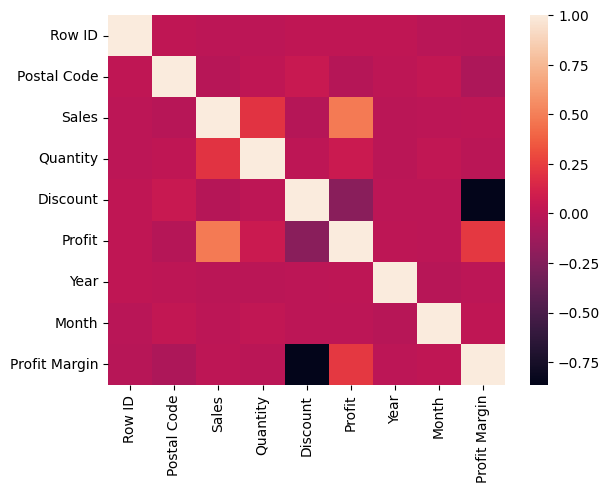

In [ ]:
sns.heatmap(data.corr(numeric_only='True'))

In [ ]:
customer_summary = data.groupby('Customer ID').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()
customer_summary.head()


,Customer ID,Sales,Profit,Quantity
0,AA-10315,5563.560,-362.8825,30
1,AA-10375,1056.390,277.3824,41
2,AA-10480,1790.512,435.8274,36
3,AA-10645,5086.935,857.8033,64
4,AB-10015,886.156,129.3465,13


In [ ]:
top_customers = customer_summary.sort_values(by='Profit', ascending=False).head(10)
top_customers


,Customer ID,Sales,Profit,Quantity
741,TC-20980,19052.218,8981.3239,42
621,RB-19360,15117.339,6976.0959,71
669,SC-20095,14142.334,5757.4119,87
327,HL-15040,12873.298,5622.4292,50
6,AB-10105,14473.571,5444.8055,73
730,TA-21385,14595.620,4703.7883,36
160,CM-12385,8954.020,3899.8904,34
424,KD-16495,8181.256,3038.6254,84
48,AR-10540,6608.448,2884.6208,33
234,DR-12940,8350.868,2869.0760,57


In [ ]:
seg= data.groupby(['Segment']).agg({
    'Sales':'sum',
    'Profit':'sum',
    'Customer ID':'nunique'
}).reset_index()
seg

,Segment,Sales,Profit,Customer ID
0,Consumer,1.161401e+06,134119.2092,409
1,Corporate,7.061464e+05,91979.1340,236
2,Home Office,4.296531e+05,60298.6785,148


In [ ]:
reg= data.groupby(['Region']).agg({
    'Sales':'sum',
    'Profit':'sum',
    'Customer ID':'nunique','Quantity':'sum'
})
reg

,Sales,Profit,Customer ID,Quantity
Region,,,,
Central,501239.8908,39706.3625,629,8780
East,678781.2400,91522.7800,674,10618
South,391721.9050,46749.4303,512,6209
West,725457.8245,108418.4489,686,12266


In [ ]:
data.groupby('City')['Profit'].sum().sort_values(ascending=False).head(5)


,Profit
City,
New York City,62036.9837
Los Angeles,30440.7579
Seattle,29156.0967
San Francisco,17507.3854
Detroit,13181.7908


In [ ]:
data.groupby('City')['Profit'].sum().sort_values(ascending=True).head(5)

,Profit
City,
Philadelphia,-13837.7674
Houston,-10153.5485
San Antonio,-7299.0502
Lancaster,-7239.0684
Chicago,-6654.5688


In [ ]:
data.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'sum','Quantity':'sum'
}).sort_values(by='Profit', ascending=False)

,Sales,Profit,Discount,Quantity
Category,,,,
Technology,836154.0330,145454.9481,244.40,6939
Office Supplies,719047.0320,122490.8008,947.80,22906
Furniture,741999.7953,18451.2728,368.89,8028


In [ ]:
top_lost_products = data.groupby('Product Name')['Profit'].sum().sort_values(ascending=True).head(5)
top_lost_products

,Profit
Product Name,
Cubify CubeX 3D Printer Double Head Print,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
Bush Advantage Collection Racetrack Conference Table,-1934.3976


In [ ]:
top_profit_products = data.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(5)
top_profit_products

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766


In [ ]:
data.groupby('Sub-Category')['Sales'].mean()

,Sales
Sub-Category,
Accessories,215.974604
Appliances,230.755710
Art,34.068834
Binders,133.560560
Bookcases,503.859633
Chairs,532.332420
Copiers,2198.941618
Envelopes,64.867724
Fasteners,13.936774


In [ ]:
data.groupby(['Sub-Category']).agg({
    'Sales':'sum',
    'Profit':'sum','Quantity':'sum','Discount':'sum','Sales':'mean'}).sort_values(by='Profit',ascending=False)

,Sales,Profit,Quantity,Discount
Sub-Category,,,,
Copiers,2198.941618,55617.8249,234,11.00
Phones,371.211534,44515.7306,3289,137.40
Accessories,215.974604,41936.6357,2976,60.80
Paper,57.284092,34053.5693,5178,102.60
Binders,133.560560,30221.7633,5974,567.00
Chairs,532.332420,26590.1663,2356,105.00
Storage,264.590553,21278.8264,3158,63.20
Appliances,230.755710,18138.0054,1729,77.60
Furnishings,95.825668,13059.1436,3563,132.40


In [ ]:
data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Profit Margin
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,0.1600
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,0.3000
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,0.4700
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,-0.4000
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,0.1125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2014,1,0.1625
9990,9991,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2017,2,0.1700
9991,9992,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2017,2,0.0750
9992,9993,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2017,2,0.4500


In [ ]:
subcat_profit = data.groupby('Sub-Category')['Profit'].sum()

# Yalnız mənfi toplam profit olan sub-category-lər
negative_subcat = subcat_profit[subcat_profit < 0]
negative_subcat

,Profit
Sub-Category,
Bookcases,-3472.5560
Supplies,-1189.0995
Tables,-17725.4811


In [ ]:
#bu 3 mehsul bize toplamda xeyir yox ziyan verib ,riskli mehsullardir

In [ ]:
a=data[data['Sub-Category']=='Bookcases'].groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'sum'})
a[a['Profit']<0]

,Sales,Profit,Discount
Product Name,,,
"Atlantic Metals Mobile 2-Shelf Bookcases, Custom Colors",400.0268,-113.2606,1.02
"Atlantic Metals Mobile 4-Shelf Bookcases, Custom Colors",5184.0810,-126.4410,1.60
Bestar Classic Bookcase,1897.8102,-612.9387,2.52
"Bush Birmingham Collection Bookcase, Dark Cherry",825.1740,-117.8820,0.30
"Bush Heritage Pine Collection 5-Shelf Bookcase, Albany Pine Finish, *Special Order",3626.0056,-208.6504,1.87
"Bush Saratoga Collection 5-Shelf Bookcase, Hanover Cherry, *Special Order",119.8330,-12.6882,0.15
Bush Somerset Collection Bookcase,1263.9570,-56.3214,0.85
"Bush Westfield Collection Bookcases, Dark Cherry Finish",649.3760,-97.4064,0.70
"Bush Westfield Collection Bookcases, Dark Cherry Finish, Fully Assembled",90.8820,-190.8522,0.70


In [ ]:
# Umumi baxanda bookcase sub-category bize ziyan versede icinde hem bize xeyir veren hemde ziyan veren mehsullar var,
#burada da bize ziyan veren mehsullarin adlari qeyd olunmusdur

In [ ]:
a=data[data['Sub-Category']=='Bookcases'].groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'sum'})
a[a['Profit']>0]

,Sales,Profit,Discount
Product Name,,,
"Atlantic Metals Mobile 3-Shelf Bookcases, Custom Colors",7539.7122,780.3302,1.47
"Atlantic Metals Mobile 5-Shelf Bookcases, Custom Colors",5492.8850,15.0490,2.53
"Bush Andora Bookcase, Maple/Graphite Gray Finish",3317.7235,135.5887,1.50
"Bush Cubix Collection Bookcases, Fully Assembled",729.2340,48.6156,0.70
Bush Mission Pointe Library,748.8608,24.1568,0.52
"Bush Westfield Collection Bookcases, Fully Assembled",1473.2982,73.7154,1.17
DMI Eclipse Executive Suite Bookcases,11046.6090,90.1764,1.10
"Global Adaptabilites Bookcase, Cherry/Storm Gray Finish",3447.8400,206.8704,0.00
"Hon Metal Bookcases, Gray",851.7600,229.9752,0.00


In [ ]:
#Bookcase sub_categoryisi uzre musbet profit gosteren product_nameler

In [ ]:
b=data[data['Sub-Category']=='Supplies'].groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'sum'})
b[b['Profit']<0]

,Sales,Profit,Discount
Product Name,,,
Acco Side-Punched Conventional Columnar Pads,41.640,-7.807500e+00,0.8
Acme Rosewood Handle Letter Opener,43.670,-3.493600e+00,0.2
Acme Serrated Blade Letter Opener,13.992,-1.749000e+00,0.2
Compact Automatic Electric Letter Opener,2982.750,-5.726880e+01,0.4
High Speed Automatic Electric Letter Opener,17030.312,-2.620048e+02,0.2
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1.299184e+03,0.6
Martin-Yale Premier Letter Opener,236.992,-1.288000e+01,0.6
Premier Automatic Letter Opener,2836.366,-4.278586e+02,0.6
Premier Electric Letter Opener,2641.608,-7.105427e-15,0.6


In [ ]:
#Supplies sub_categoryisi uzre menfi profit gosteren product_nameler

In [ ]:
c=data[data['Sub-Category']=='Tables'].groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'sum'})
c[c['Profit']<0]

,Sales,Profit,Discount
Product Name,,,
Anderson Hickey Conga Table Tops & Accessories,51.7820,-17.5145,0.60
BPI Conference Tables,2241.8675,-795.9725,1.85
Balt Solid Wood Rectangular Table,828.0965,-216.2545,1.05
Balt Solid Wood Round Tables,6518.7540,-1201.0581,0.80
Balt Split Level Computer Training Table,1040.6250,-357.9750,1.90
"Barricks 18"" x 48"" Non-Folding Utility Table with Bottom Storage Shelf",1088.6400,-104.8320,1.60
Bevis 44 x 96 Conference Tables,3253.2200,-164.7200,0.90
Bevis Boat-Shaped Conference Table,2542.4670,-445.5870,1.90
"Bevis Oval Conference Table, Walnut",6942.0680,-856.0144,2.20


In [ ]:
#Tables sub_categoryisi uzre menfi profit gosteren product_nameler

In [ ]:
ziyanli_meh=data[data['Sub-Category'].isin(['Bookcases','Tables','Supplies'])]

In [ ]:
ziyanli_meh[ziyanli_meh['Sub-Category']].groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'sum'})

KeyError: "None of [Index(['Bookcases', 'Tables', 'Tables', 'Tables', 'Bookcases', 'Bookcases',\n       'Tables', 'Tables', 'Supplies', 'Supplies',\n       ...\n       'Tables', 'Bookcases', 'Tables', 'Supplies', 'Supplies', 'Tables',\n       'Supplies', 'Bookcases', 'Tables', 'Supplies'],\n      dtype='object', length=737)] are in the [columns]"

In [ ]:
data[data['Sub-Category']=='Bookcases'].groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'sum'})

In [ ]:
ziyanli_meh.groupby(['Segment','Ship Mode']).agg({
    'Sales':'sum',
    'Profit':'sum',
    'Quantity':'sum','Discount':'sum'})


Sales      Profit  Quantity  Discount
Segment     Ship Mode                                                  
Consumer    First Class      20144.4070   -636.9134       194     11.11
            Same Day          6118.8060   -661.7735        59      3.85
            Second Class     52838.9856  -3846.7152       315     17.76
            Standard Class  115205.8214 -10675.8252       889     47.59
Corporate   First Class      17927.9049    206.9942       149      7.42
            Same Day          4879.2240     43.3152        53      1.60
            Second Class     30232.8418  -1671.8580       173      7.99
            Standard Class   71272.9551  -2507.5734       517     28.34
Home Office First Class      15362.0770  -1128.3386        94      5.44
            Same Day          2127.2090    -39.4584        26      1.30
            Second Class     12307.5430    664.3096        96      2.80
            Standard Class   20101.2915  -2133.2999       191     10.89

In [ ]:
ziyanli_meh.groupby(['Region']).agg({
    'Sales':'sum',
    'Profit':'sum',
    'Quantity':'sum','Discount':'sum'})

,Sales,Profit,Quantity,Discount
Region,,,,
Central,72779.5198,-6219.4428,576,35.74
East,93719.2570,-13348.1471,718,49.10
South,63134.4820,-3281.6888,437,17.15
West,138885.8075,462.1421,1025,44.10


In [ ]:
loss = data[data['Profit Margin']<0]
loss[['Order ID','Sales','Profit Margin','Profit','Discount']].head()

,Order ID,Sales,Profit Margin,Profit,Discount
3,US-2015-108966,957.5775,-0.400000,-383.0310,0.45
14,US-2015-118983,68.8100,-1.800000,-123.8580,0.80
15,US-2015-118983,2.5440,-1.500000,-3.8160,0.80
23,US-2017-156909,71.3720,-0.014286,-1.0196,0.30
27,US-2015-150630,3083.4300,-0.540000,-1665.0522,0.50


In [ ]:
loss.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'sum','Quantity':'sum'
}).sort_values(by='Profit', ascending=False)

,Sales,Profit,Discount,Quantity
Category,,,,
Technology,119212.8930,-38579.9182,90.40,963
Office Supplies,91608.6750,-56615.2585,547.20,3425
Furniture,257885.5868,-60936.1090,262.14,2652


In [ ]:
loss.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'sum'
}).sort_values(by='Profit', ascending=False)


,Sales,Profit,Discount
Sub-Category,,,
Fasteners,149.2800,-33.1952,2.40
Accessories,10958.8000,-930.6265,18.20
Supplies,14067.1760,-3015.6219,6.60
Storage,37869.0720,-6426.3038,32.20
Furnishings,12845.8440,-6490.9134,88.60
Phones,35797.8400,-7530.6235,46.60
Appliances,3382.5340,-8629.6412,53.60
Chairs,91988.4560,-9880.8413,61.40
Bookcases,48072.7408,-12152.2060,37.99


In [ ]:
officeloss=loss[loss['Category']=='Office Supplies']

In [ ]:
officeloss.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'sum'
}).sort_values(by='Profit', ascending=False)

,Sales,Profit,Discount
Sub-Category,,,
Fasteners,149.280,-33.1952,2.4
Supplies,14067.176,-3015.6219,6.6
Storage,37869.072,-6426.3038,32.2
Appliances,3382.534,-8629.6412,53.6
Binders,36140.613,-38510.4964,452.4


In [ ]:
data[data['Sub-Category']=='Bookcases'].groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'sum'})

,Sales,Profit,Discount
Product Name,,,
"Atlantic Metals Mobile 2-Shelf Bookcases, Custom Colors",400.0268,-113.2606,1.02
"Atlantic Metals Mobile 3-Shelf Bookcases, Custom Colors",7539.7122,780.3302,1.47
"Atlantic Metals Mobile 4-Shelf Bookcases, Custom Colors",5184.0810,-126.4410,1.60
"Atlantic Metals Mobile 5-Shelf Bookcases, Custom Colors",5492.8850,15.0490,2.53
Bestar Classic Bookcase,1897.8102,-612.9387,2.52
"Bush Andora Bookcase, Maple/Graphite Gray Finish",3317.7235,135.5887,1.50
"Bush Birmingham Collection Bookcase, Dark Cherry",825.1740,-117.8820,0.30
"Bush Cubix Collection Bookcases, Fully Assembled",729.2340,48.6156,0.70
"Bush Heritage Pine Collection 5-Shelf Bookcase, Albany Pine Finish, *Special Order",3626.0056,-208.6504,1.87


In [ ]:
#Office Supplies kateqoriyasına aid Binders məhsulları yüksək satışa baxmayaraq mənfi profit göstərir. Bu, əsasən yüksək endirimlərlə əlaqəlidir

In [ ]:
data.groupby('Ship Mode').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
})

,Sales,Profit,Quantity
Ship Mode,,,
First Class,3.514284e+05,48969.8399,5693
Same Day,1.283631e+05,15891.7589,1960
Second Class,4.591936e+05,57446.6354,7423
Standard Class,1.358216e+06,164088.7875,22797


In [ ]:
#Standard Class ən effektiv üsuldur. First Class və Same Day isə sürətli olsa da, daha az istifadə olunur və nisbətən aşağı profit gətirir.

In [ ]:
data_binders=loss[(loss['Sub-Category']=='Binders') | (loss['Sub-Category']=='Appliances')]
data_binders.groupby('Ship Mode').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'sum','Quantity':'sum'})

,Sales,Profit,Discount,Quantity
Ship Mode,,,,
First Class,7277.745,-7485.5074,84.2,466
Same Day,739.923,-959.7092,23.6,116
Second Class,5182.440,-5814.3261,68.2,376
Standard Class,26323.039,-32880.5949,330.0,1733


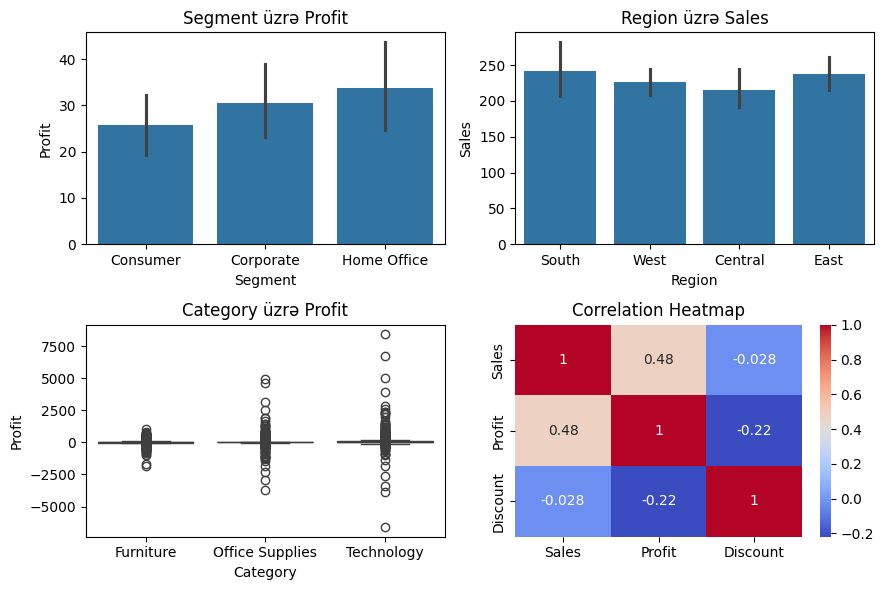

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,6))

# Segment üzrə Profit
plt.subplot(2,2,1)
sns.barplot(x='Segment', y='Profit', data=data)
plt.title("Segment üzrə Profit")

# Region üzrə Sales
plt.subplot(2,2,2)
sns.barplot(x='Region', y='Sales', data=data)
plt.title("Region üzrə Sales")

# Category üzrə Profit Margin
plt.subplot(2,2,3)
sns.boxplot(x='Category', y='Profit', data=data)
plt.title("Category üzrə Profit")

# Heatmap
plt.subplot(2,2,4)
sns.heatmap(data[['Sales','Profit','Discount']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()


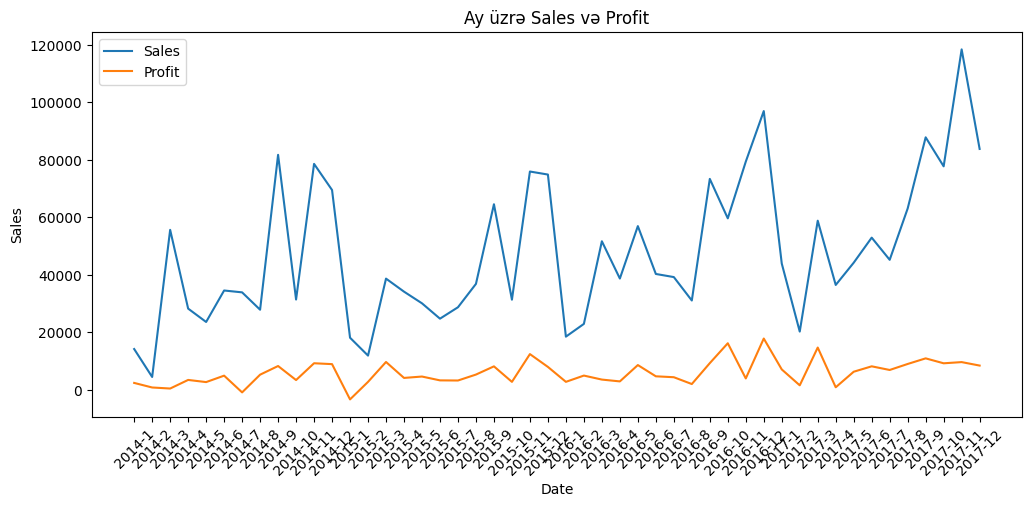

In [ ]:
# Hər il və ay üçün toplam satış və profit
monthly = data.groupby(['Year', 'Month'])[['Sales','Profit']].sum().reset_index()
monthly['Date'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x='Date', y='Sales', label='Sales')
sns.lineplot(data=monthly, x='Date', y='Profit', label='Profit')
plt.xticks(rotation=45)  # tarixləri oxumaq üçün
plt.title("Ay üzrə Sales və Profit")
plt.show()


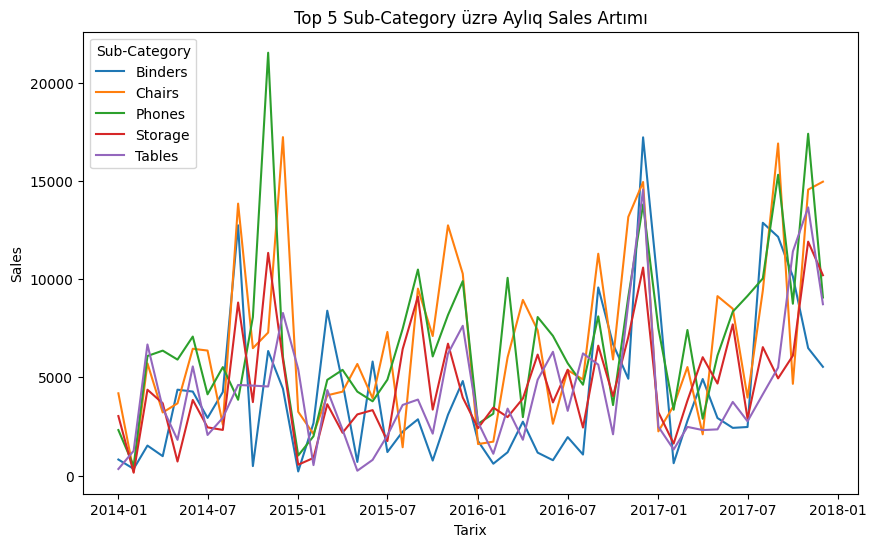

In [ ]:
monthly_sub = data.groupby(['Year','Month','Sub-Category'])['Sales'].sum().reset_index()
monthly_sub['Date'] = pd.to_datetime(
    monthly_sub['Year'].astype(str) + '-' + monthly_sub['Month'].astype(str) + '-01')
top5 = data.groupby('Sub-Category')['Sales'].sum().nlargest(5).index
plot_data = monthly_sub[monthly_sub['Sub-Category'].isin(top5)]


plt.figure(figsize=(10,6))
sns.lineplot(data=plot_data,x='Date',y='Sales',hue='Sub-Category')

plt.title('Top 5 Sub-Category üzrə Aylıq Sales Artımı')
plt.xlabel('Tarix')
plt.ylabel('Sales')

plt.show()


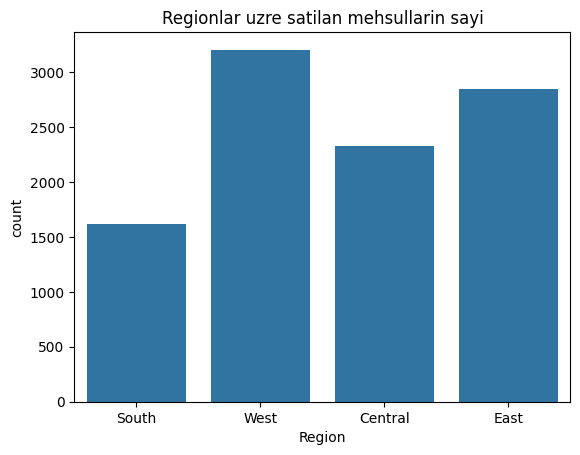

In [ ]:
sns.countplot(x='Region', data=data)
plt.title('Regionlar uzre satilan mehsullarin sayi', fontsize=12)
plt.show()

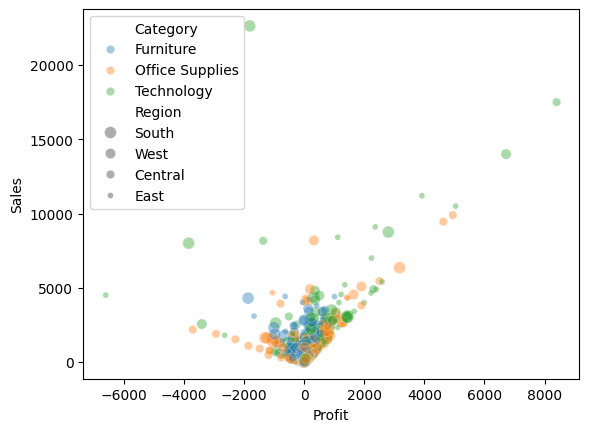

In [ ]:
sns.scatterplot(x='Profit', y='Sales', size='Region', hue='Category', data=data, alpha=0.4)
plt.show()

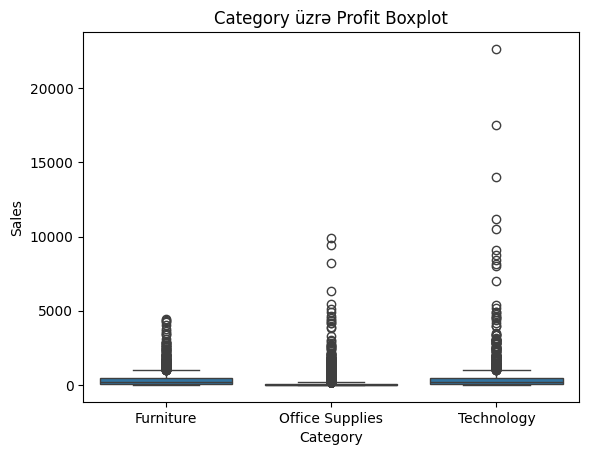

In [ ]:
sns.boxplot(x='Category', y='Sales', data=data)
plt.title('Category üzrə Profit Boxplot')
plt.show()

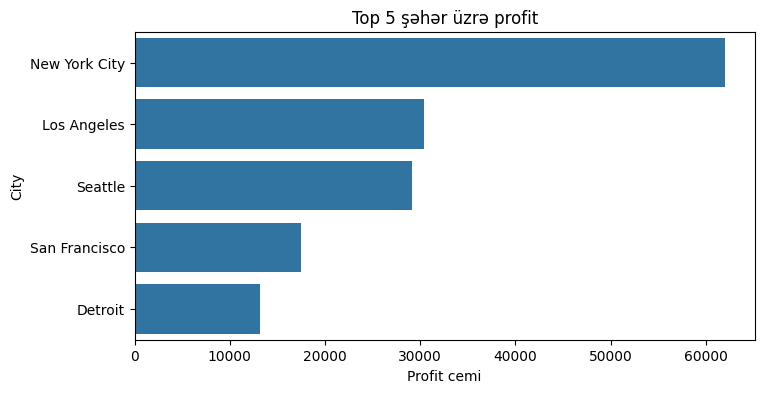

In [ ]:
city_profit=data.groupby('City')['Profit'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,4))
sns.barplot(x=city_profit.values,y=city_profit.index)
plt.title('Top 5 şəhər üzrə profit')
plt.xlabel('Profit cemi')
plt.ylabel('City')
plt.show()

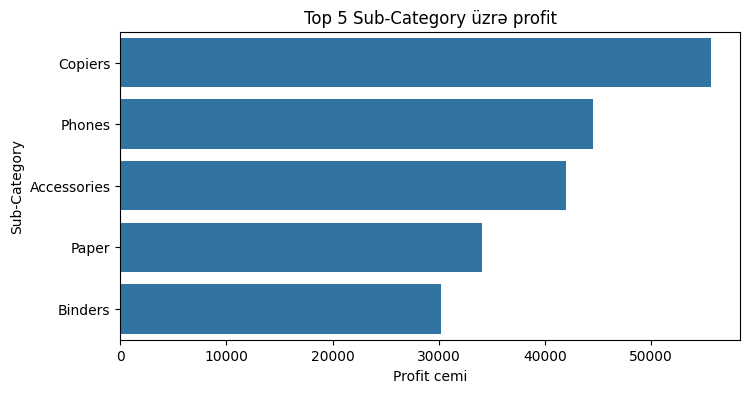

In [ ]:
category_profit=data.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,4))
sns.barplot(x=category_profit.values,y=category_profit.index)
plt.title('Top 5 Sub-Category üzrə profit')
plt.xlabel('Profit cemi')
plt.ylabel('Sub-Category')
plt.show()

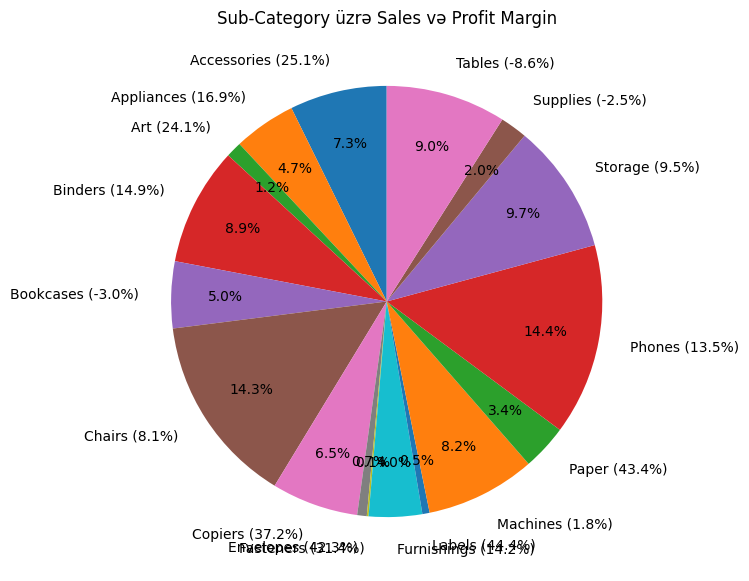

In [ ]:
sub_data = data.groupby('Sub-Category').agg({'Sales':'sum','Profit':'sum'}).reset_index()
sub_data['Profit_Margin'] = (sub_data['Profit'] / sub_data['Sales']) * 100
labels = sub_data['Sub-Category'] + ' (' + sub_data['Profit_Margin'].round(1).astype(str) + '%)'
import matplotlib.pyplot as plt
plt.figure(figsize=(7,7))
plt.pie(
    sub_data['Sales'],
    labels=labels,
    startangle=90,
autopct='%1.1f%%',
    labeldistance=1.15,
    pctdistance=0.75)
plt.title('Sub-Category üzrə Sales və Profit Margin')
plt.show()


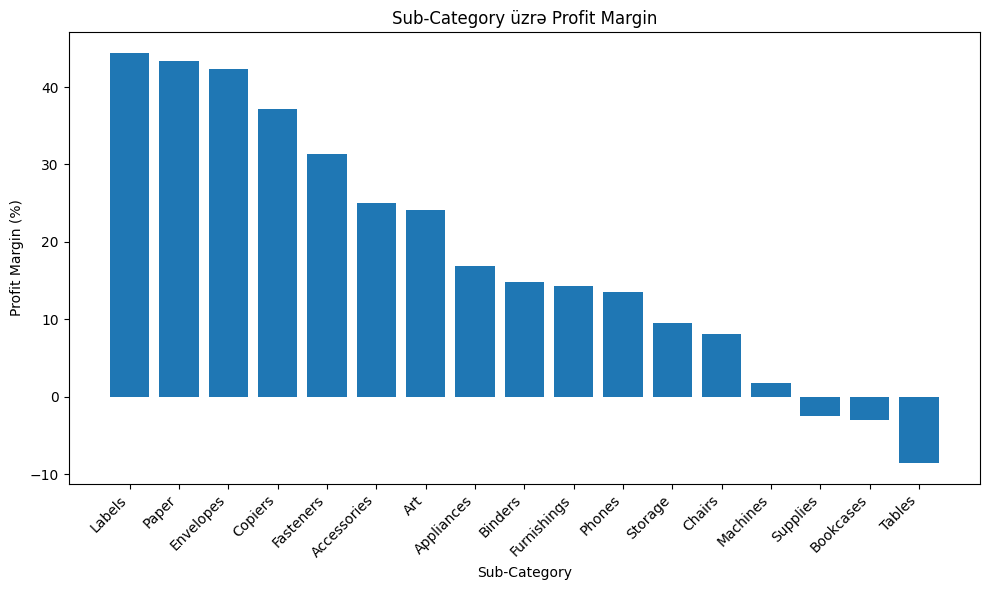

In [ ]:
import matplotlib.pyplot as plt

# Profit margin-ə görə sırala (azalan)
sub_sorted = sub_data.sort_values('Profit_Margin', ascending=False)

plt.figure(figsize=(10,6))

plt.bar(
    sub_sorted['Sub-Category'],
    sub_sorted['Profit_Margin']
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Profit Margin (%)')
plt.xlabel('Sub-Category')
plt.title('Sub-Category üzrə Profit Margin')

plt.tight_layout()
plt.show()
